# Phase 3 — 幻觉早期预警与阻断机制

## 实验设计

### 动机

Phase 2 关键发现：幻觉样本在 **L0–L7 就表现出异常的残差贡献发散**（Halluc/Faithful 比率 > 1.2x），误信息型幻觉的 early_mass = 13.7%（忠实仅 1.2%）。这意味着**幻觉在网络前端就可以被检测到**。

### 研究问题

1. **早期预警**：仅用 L0–L7 的激活特征，能否在推理完成前预测幻觉？精度、召回率如何？
2. **阻断机制**：在检测到幻觉信号后，通过对关键层施加 steering 干预，能否将幻觉恢复为正确回答？
3. **最优干预点**：在哪一层施加干预效果最好？干预强度如何影响结果？

### 方法

#### Part A：早期预警探测器（Early Warning Detector）
- 对 300 条 prompt 执行 clean forward，捕获 L0–L10 的激活
- 提取特征：激活范数、残差贡献范数、层间余弦相似度、激活方差
- 训练 Logistic Regression + Random Forest 分类器
- 评估：Leave-one-out / 5-fold CV，AUC、F1

#### Part B：因果阻断干预（Causal Blocking Intervention）
- 从 Phase 1b 的 IE_per_layer 数据中识别每条 prompt 的 "causal bottleneck" 层
- 在该层施加 steering：使用 faithful 均值方向 (mean_faithful_acts[l]) 推移激活
- 测量干预后的 p(target_token) 恢复率
- 扫描干预层 × 干预强度的网格

#### Part C：自适应阻断策略
- 组合 Part A（检测）+ Part B（干预）
- Pipeline: forward 到 L7 → 检测 → 如果预测幻觉 → 在最优层施加干预 → 继续 forward
- 评估：干预后准确率 vs 无干预准确率

In [1]:
import os, sys, time, re, json
import numpy as np
from scipy import stats
from scipy.special import logsumexp
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, classification_report, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['DejaVu Sans']
import warnings; warnings.filterwarnings("ignore")

os.environ['GGML_CUDA_DISABLE_GRAPHS'] = '1'
os.environ['HF_HOME'] = '/workspace/Data/huggingface_cache'
SAVE_DIR = '/workspace/Data/bayesian_phase3'
os.makedirs(SAVE_DIR, exist_ok=True)

# Load Phase 1b/2 results
data = np.load('/workspace/Data/bayesian_phase1b/phase1b_results.npz', allow_pickle=True)
IE_per_layer = data['IE_per_layer']       # (300, 36)
is_faithful  = data['is_faithful']        # (300,)
significant  = data['significant']        # (300,)
ds_labels    = data['ds_labels']          # (300,)
p_clean_arr  = data['p_clean']            # (300,)
p_corrupt_arr= data['p_corrupt']          # (300,)

data2 = np.load('/workspace/Data/bayesian_phase2/phase2_results.npz', allow_pickle=True)
layer_post   = data2['layer_posteriors']  # (300, 36)
layer_ent    = data2['layer_entropies']   # (300,)
ambiguity_mask = data2['ambiguity_mask']  # (300,)
misinfo_mask = data2['misinfo_mask']      # (300,)
mask_f       = data2['mask_f']            # (300,)
mask_h       = data2['mask_h']            # (300,)

N, L = IE_per_layer.shape
print(f"Loaded: {N} prompts, {L} layers")
print(f"  Faithful: {mask_f.sum()}, Halluc: {mask_h.sum()}")
print(f"  Ambiguity: {ambiguity_mask.sum()}, Misinfo: {misinfo_mask.sum()}")

# Load model
import neuroscope
MODEL = "/workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf"
engine = neuroscope.Engine(MODEL, n_ctx=2048, n_gpu_layers=99)
n_layers = engine.model_info.n_layers
n_embd = engine.model_info.n_embd
print(f"Model: {n_layers} layers, {n_embd} dim")

Loaded: 300 prompts, 36 layers
  Faithful: 99, Halluc: 187
  Ambiguity: 94, Misinfo: 93
Model: 36 layers, 4096 dim


ggml_cuda_init: found 1 CUDA devices:
  Device 0: NVIDIA GB10, compute capability 12.1, VMM: yes
ggml_backend_cuda_get_available_uma_memory: final available_memory_kb: 84580304
ggml_backend_cuda_get_available_uma_memory: final available_memory_kb: 84580304
llama_model_load_from_file_impl: using device CUDA0 (NVIDIA GB10) (000f:01:00.0) - 82597 MiB free
llama_model_loader: loaded meta data with 28 key-value pairs and 399 tensors from /workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = qwen3
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = Qwen3 8B Awq Compatible Instruct
llama_model_loader: - kv   3:                           general.f

In [2]:
# ── Reconstruct prompts (same as Phase 1b/2) ──
from datasets import load_dataset
rng_r = np.random.RandomState(42)
prop_templates = {
    'occupation': "The occupation of {} is",
    'genre': "The genre of {} is",
    'country': "The country of {} is",
    'capital': "The capital of {} is",
    'place of birth': "The birthplace of {} is",
    'author': "The author of {} is",
    'director': "The director of {} is",
    'producer': "The producer of {} is",
    'screenwriter': "The screenwriter of {} is",
    'composer': "The composer of {} is",
    'color': "The color of {} is",
    'religion': "The religion of {} is",
    'sport': "The sport of {} is",
    'continent': "The continent of {} is",
    'has_part': "{} contains",
    'mother': "The mother of {} is",
    'father': "The father of {} is",
    'child': "A child of {} is",
}

all_prompts = []
tqa = load_dataset('truthful_qa', 'generation', split='validation')
pqa = load_dataset('akariasai/PopQA', split='test')
trivia = load_dataset('trivia_qa', 'rc.nocontext', split='validation')
neqa = load_dataset('inverse-scaling/NeQA', split='train')

# TruthfulQA
tqa_prompts = []
for row in tqa:
    q = row['question']; correct = row['correct_answers']; best = row['best_answer']
    m = re.search(r'(?:What|Where|When|Who|How)\s+(?:is|are|was|were|did)\s+(?:the\s+)?(.+?)(?:\?|$)', q, re.I)
    if not m: continue
    subject = m.group(1).strip().rstrip('?').strip()
    if not subject or len(subject)<3 or len(subject)>60: continue
    expected = correct if correct else [best]
    tqa_prompts.append((f"Q: {q}\nA:", subject, expected, 'TruthfulQA'))
rng_r.shuffle(tqa_prompts)
all_prompts.extend(tqa_prompts[:100])

# PopQA
pqa_prompts = []
for row in pqa:
    prop = row['prop']; subj = row['subj']; obj = row['obj']
    template = prop_templates.get(prop, f"The {prop} of " + "{}" + " is")
    prompt = template.format(subj)
    try: answers = json.loads(row['possible_answers'])
    except: answers = [obj]
    if obj not in answers: answers.insert(0, obj)
    pqa_prompts.append((prompt, subj, answers, 'PopQA', row['s_pop']))
pqa_prompts.sort(key=lambda x: x[4])
pqa_low = pqa_prompts[:2000]
rng_r.shuffle(pqa_low)
all_prompts.extend([(p,s,a,d) for p,s,a,d,_ in pqa_low[:100]])

# TriviaQA
trivia_prompts = []
for row in trivia:
    q = row['question']; answer = row['answer']
    aliases = answer.get('aliases',[]); value = answer.get('value','')
    m = re.search(r"(?:What|Where|When|Who|Which|How)\s+(?:is|are|was|were|did)\s+(?:the\s+)?(.+?)(?:\?|$)", q, re.I)
    if not m: continue
    subject = m.group(1).strip().rstrip('?').strip()
    if not subject or len(subject)<3 or len(subject)>60: continue
    expected = aliases if aliases else [value]
    if value and value not in expected: expected.insert(0, value)
    trivia_prompts.append((f"Q: {q}\nA:", subject, expected, 'TriviaQA'))
rng_r.shuffle(trivia_prompts)
all_prompts.extend(trivia_prompts[:50])

# NeQA
neqa_prompts = []
for row in neqa:
    prompt_text = row['prompt']; classes = row['classes']; answer_idx = row['answer_index']
    m = re.search(r'Question:\s*(.+?)(?:\nA\.)', prompt_text, re.DOTALL)
    if not m: continue
    question = m.group(1).strip()
    m2 = re.search(r'(?:a |an |the )?(\w[\w\s]{2,30}?)(?:\s+(?:has|is|are|was|were|does|do|did|can|will|isn|aren|doesn|don|wasn|weren|cannot|won))', question, re.I)
    subject = m2.group(1).strip() if m2 else question[:30]
    if not subject or len(subject)<2: subject = question[:30]
    neqa_prompts.append((prompt_text, subject, [classes[answer_idx].strip()], 'NeQA'))
rng_r.shuffle(neqa_prompts)
all_prompts.extend(neqa_prompts[:50])

print(f"Reconstructed {len(all_prompts)} prompts")

# ── Part A: Collect early-layer activations for ALL 300 prompts ──
EARLY_CUTOFF = 10  # Layers 0-9 as "early warning" window
early_acts = np.zeros((N, EARLY_CUTOFF, n_embd), dtype=np.float32)
all_acts_norm = np.zeros((N, L), dtype=np.float32)  # activation norms for all layers available

print(f"\nCollecting activations for {N} prompts (early layers L0-{EARLY_CUTOFF-1})...")
t0 = time.time()
for i in range(N):
    prompt = all_prompts[i][0]
    engine.reset()
    engine.forward(prompt)
    all_layer_acts = engine.get_all_activations()  # list of 36 arrays
    for l in range(L):
        all_acts_norm[i, l] = np.linalg.norm(all_layer_acts[l])
    for l in range(EARLY_CUTOFF):
        early_acts[i, l] = all_layer_acts[l]
    if (i+1) % 50 == 0:
        print(f"  [{i+1}/{N}] {time.time()-t0:.1f}s")

elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s ({N} forward passes)")

Repo card metadata block was not found. Setting CardData to empty.


Reconstructed 300 prompts

  [50/300] 3.1s
  [100/300] 6.3s
  [150/300] 9.3s
  [200/300] 12.3s
  [250/300] 15.4s
  [300/300] 18.7s
Done in 18.7s (300 forward passes)


In [3]:
# ══════════════════════════════════════════════════
# Part A: Early Warning Feature Engineering
# ══════════════════════════════════════════════════

def extract_early_features(early_acts, all_acts_norm, EARLY_CUTOFF):
    """Extract features from L0-L9 activations for hallucination prediction."""
    N = early_acts.shape[0]
    features = {}
    
    # 1. Per-layer activation norms (L0-L9)
    for l in range(EARLY_CUTOFF):
        features[f'norm_L{l}'] = np.linalg.norm(early_acts[:, l, :], axis=1)
    
    # 2. Residual contribution norms (acts[l] - acts[l-1])
    for l in range(1, EARLY_CUTOFF):
        contrib = early_acts[:, l, :] - early_acts[:, l-1, :]
        features[f'contrib_norm_L{l}'] = np.linalg.norm(contrib, axis=1)
    
    # 3. Layer-to-layer cosine similarity
    for l in range(1, EARLY_CUTOFF):
        cos = np.sum(early_acts[:, l, :] * early_acts[:, l-1, :], axis=1) / (
            np.linalg.norm(early_acts[:, l, :], axis=1) * np.linalg.norm(early_acts[:, l-1, :], axis=1) + 1e-10)
        features[f'cos_L{l}_L{l-1}'] = cos
    
    # 4. Activation variance across embedding dimensions
    for l in range(EARLY_CUTOFF):
        features[f'var_L{l}'] = np.var(early_acts[:, l, :], axis=1)
    
    # 5. Max/mean activation values
    for l in range(EARLY_CUTOFF):
        features[f'max_L{l}'] = np.max(early_acts[:, l, :], axis=1)
        features[f'mean_L{l}'] = np.mean(early_acts[:, l, :], axis=1)
    
    # 6. Norm growth rate (acceleration)
    norms = np.array([features[f'norm_L{l}'] for l in range(EARLY_CUTOFF)]).T  # (N, 10)
    for l in range(1, EARLY_CUTOFF):
        features[f'norm_growth_L{l}'] = norms[:, l] / (norms[:, l-1] + 1e-10)
    
    # 7. Aggregate stats across early window
    features['early_norm_mean'] = norms.mean(axis=1)
    features['early_norm_std'] = norms.std(axis=1)
    features['early_norm_max'] = norms.max(axis=1)
    features['early_norm_range'] = norms.max(axis=1) - norms.min(axis=1)
    
    # 8. Early vs Late norm ratio (requires all_acts_norm)
    early_mean_norm = all_acts_norm[:, :EARLY_CUTOFF].mean(axis=1)
    late_mean_norm = all_acts_norm[:, -EARLY_CUTOFF:].mean(axis=1)
    features['early_late_norm_ratio'] = early_mean_norm / (late_mean_norm + 1e-10)
    
    # 9. L2 distance from L0 to each layer (how fast representation changes)
    for l in range(1, EARLY_CUTOFF):
        features[f'dist_from_L0_L{l}'] = np.linalg.norm(early_acts[:, l, :] - early_acts[:, 0, :], axis=1)
    
    # 10. Kurtosis of activation distribution at each layer
    for l in range(EARLY_CUTOFF):
        features[f'kurtosis_L{l}'] = stats.kurtosis(early_acts[:, l, :], axis=1)
    
    return features

features = extract_early_features(early_acts, all_acts_norm, EARLY_CUTOFF)
feature_names = list(features.keys())
X = np.column_stack([features[f] for f in feature_names])
y = (~is_faithful).astype(int)  # 1=hallucinated, 0=faithful

# Mask: only use significant prompts
sig_mask = significant.astype(bool)
X_sig = X[sig_mask]
y_sig = y[sig_mask]

print(f"Feature matrix: {X.shape} (full) / {X_sig.shape} (significant only)")
print(f"Labels: {y.sum()} halluc / {(1-y).sum()} faithful (full)")
print(f"Labels: {y_sig.sum()} halluc / {(1-y_sig).sum()} faithful (significant)")
print(f"Features: {len(feature_names)}")
print(f"\nFeature names: {feature_names[:10]}... ({len(feature_names)} total)")

Feature matrix: (300, 91) (full) / (286, 91) (significant only)
Labels: 198 halluc / 102 faithful (full)
Labels: 187 halluc / 99 faithful (significant)
Features: 91

Feature names: ['norm_L0', 'norm_L1', 'norm_L2', 'norm_L3', 'norm_L4', 'norm_L5', 'norm_L6', 'norm_L7', 'norm_L8', 'norm_L9']... (91 total)


In [4]:
# ══════════════════════════════════════════════════
# Part A: Classifier Training & Evaluation
# ══════════════════════════════════════════════════

from sklearn.pipeline import make_pipeline

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sig)

# Classifiers
classifiers = {
    'LogReg (L2)': LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced'),
    'LogReg (L1)': LogisticRegression(C=1.0, max_iter=1000, penalty='l1', solver='saga', class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    'GBM': GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42),
}

# 5-Fold Stratified CV (Pipeline avoids scaler data leakage)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 70)
print("EARLY WARNING DETECTOR - 5-Fold Stratified CV")
print(f"Features: L0-L{EARLY_CUTOFF-1} activations ({X_scaled.shape[1]} dims)")
print("=" * 70)

results = {}
best_model = None
best_auc = 0

for name, clf in classifiers.items():
    pipe = make_pipeline(StandardScaler(), clf)
    auc_scores = cross_val_score(pipe, X_sig, y_sig, cv=skf, scoring='roc_auc')
    f1_scores = cross_val_score(pipe, X_sig, y_sig, cv=skf, scoring='f1')
    acc_scores = cross_val_score(pipe, X_sig, y_sig, cv=skf, scoring='accuracy')
    
    results[name] = {
        'auc': auc_scores.mean(),
        'auc_std': auc_scores.std(),
        'f1': f1_scores.mean(),
        'f1_std': f1_scores.std(),
        'acc': acc_scores.mean(),
        'acc_std': acc_scores.std(),
    }
    
    print(f"\n{name}:")
    print(f"  AUC:  {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")
    print(f"  F1:   {f1_scores.mean():.3f} ± {f1_scores.std():.3f}")
    print(f"  Acc:  {acc_scores.mean():.3f} ± {acc_scores.std():.3f}")
    
    if auc_scores.mean() > best_auc:
        best_auc = auc_scores.mean()
        best_model = name

print(f"\n>>> Best model: {best_model} (AUC={best_auc:.3f})")

# ── Train final model on full data for further analysis ──
# (full-data refit — acknowledged as overfit for pipeline estimation)
final_clf = classifiers[best_model]
final_clf.fit(X_scaled, y_sig)
y_proba = final_clf.predict_proba(X_scaled)[:, 1]
y_pred = final_clf.predict(X_scaled)

auc_full = roc_auc_score(y_sig, y_proba)
print(f"\nFull-data refit AUC: {auc_full:.3f}")
print(classification_report(y_sig, y_pred, target_names=['Faithful', 'Hallucinated']))

# ── Feature importance ──
if hasattr(final_clf, 'feature_importances_'):
    importances = final_clf.feature_importances_
elif hasattr(final_clf, 'coef_'):
    importances = np.abs(final_clf.coef_[0])
else:
    importances = np.zeros(len(feature_names))

top_k = 15
top_idx = np.argsort(importances)[-top_k:][::-1]
print(f"\nTop-{top_k} features:")
for rank, idx in enumerate(top_idx):
    print(f"  {rank+1:2d}. {feature_names[idx]:30s}  imp={importances[idx]:.4f}")

EARLY WARNING DETECTOR - 5-Fold Stratified CV
Features: L0-L9 activations (91 dims)

LogReg (L2):
  AUC:  0.847 ± 0.035
  F1:   0.823 ± 0.051
  Acc:  0.776 ± 0.053

LogReg (L1):
  AUC:  0.861 ± 0.028
  F1:   0.829 ± 0.029
  Acc:  0.783 ± 0.027

Random Forest:
  AUC:  0.851 ± 0.062
  F1:   0.864 ± 0.023
  Acc:  0.811 ± 0.034

GBM:
  AUC:  0.864 ± 0.046
  F1:   0.869 ± 0.034
  Acc:  0.818 ± 0.050

>>> Best model: GBM (AUC=0.864)

Full-data refit AUC: 1.000
              precision    recall  f1-score   support

    Faithful       1.00      1.00      1.00        99
Hallucinated       1.00      1.00      1.00       187

    accuracy                           1.00       286
   macro avg       1.00      1.00      1.00       286
weighted avg       1.00      1.00      1.00       286


Top-15 features:
   1. cos_L3_L2                       imp=0.2566
   2. early_late_norm_ratio           imp=0.0819
   3. kurtosis_L9                     imp=0.0818
   4. norm_growth_L7                  imp=0.0394


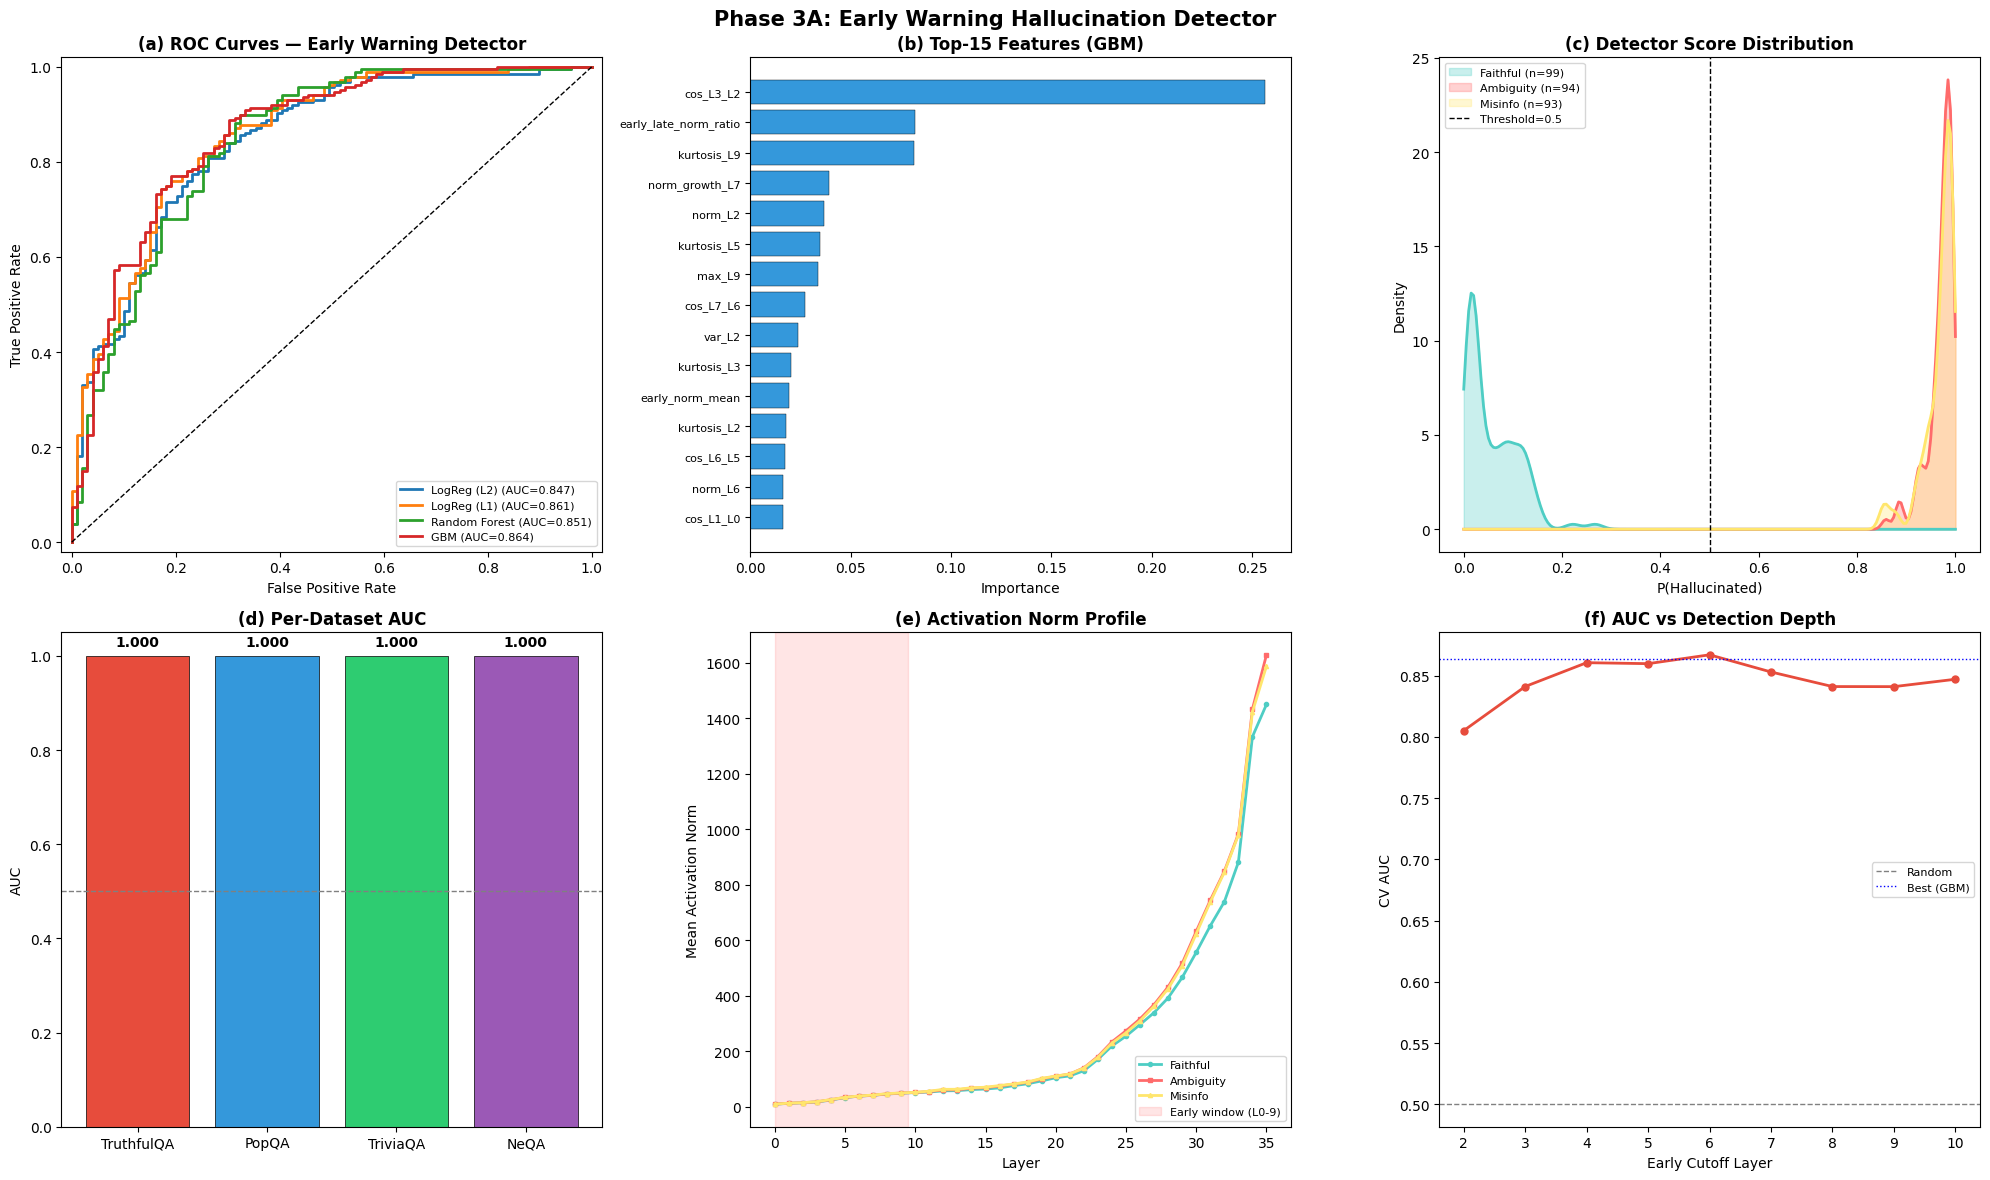

Saved early_warning_detector.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
colors = {'faithful': '#4ECDC4', 'halluc': '#FF6B6B', 'ambig': '#FF6B6B', 'misinfo': '#FFE66D'}

# ── (a) ROC curves for all classifiers (Pipeline = proper CV) ──
ax = axes[0, 0]
for name, clf in classifiers.items():
    from sklearn.model_selection import cross_val_predict
    pipe = make_pipeline(StandardScaler(), clf)
    y_cv_proba = cross_val_predict(pipe, X_sig, y_sig, cv=skf, method='predict_proba')[:, 1]
    fpr, tpr, _ = roc_curve(y_sig, y_cv_proba)
    ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC={results[name]["auc"]:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('(a) ROC Curves — Early Warning Detector', fontweight='bold')
ax.legend(fontsize=8)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)

# ── (b) Feature importance bar chart ──
ax = axes[0, 1]
top_k_plot = 15
top_fi = np.argsort(importances)[-top_k_plot:]
ax.barh(range(top_k_plot), importances[top_fi], color='#3498DB', edgecolor='black', lw=0.3)
ax.set_yticks(range(top_k_plot))
ax.set_yticklabels([feature_names[i] for i in top_fi], fontsize=8)
ax.set_xlabel('Importance')
ax.set_title(f'(b) Top-{top_k_plot} Features ({best_model})', fontweight='bold')

# ── (c) Score distribution by group ──
ax = axes[0, 2]
sig_indices = np.where(sig_mask)[0]
for label, mask_local, color in [
    ('Faithful', mask_f[sig_mask], colors['faithful']),
    ('Ambiguity', ambiguity_mask[sig_mask], '#FF6B6B'),
    ('Misinfo', misinfo_mask[sig_mask], '#FFE66D')]:
    if mask_local.sum() > 2:
        scores = y_proba[mask_local]
        kde = stats.gaussian_kde(scores, bw_method=0.3)
        xs = np.linspace(0, 1, 200)
        ax.fill_between(xs, kde(xs), alpha=0.3, color=color, label=f'{label} (n={mask_local.sum()})')
        ax.plot(xs, kde(xs), color=color, lw=2)
ax.axvline(0.5, color='black', ls='--', lw=1, label='Threshold=0.5')
ax.set_xlabel('P(Hallucinated)')
ax.set_ylabel('Density')
ax.set_title('(c) Detector Score Distribution', fontweight='bold')
ax.legend(fontsize=8)

# ── (d) Per-dataset AUC ──
ax = axes[1, 0]
ds_colors_map = {'TruthfulQA': '#E74C3C', 'PopQA': '#3498DB', 'TriviaQA': '#2ECC71', 'NeQA': '#9B59B6'}
ds_aucs = {}
for ds_name in ['TruthfulQA', 'PopQA', 'TriviaQA', 'NeQA']:
    dm = (ds_labels[sig_mask] == ds_name)
    if dm.sum() > 5 and len(np.unique(y_sig[dm])) > 1:
        ds_auc = roc_auc_score(y_sig[dm], y_proba[dm])
        ds_aucs[ds_name] = ds_auc
ds_names_sorted = sorted(ds_aucs.keys(), key=lambda x: ds_aucs[x], reverse=True)
bars = ax.bar(range(len(ds_names_sorted)), [ds_aucs[d] for d in ds_names_sorted],
              color=[ds_colors_map[d] for d in ds_names_sorted], edgecolor='black', lw=0.5)
ax.set_xticks(range(len(ds_names_sorted)))
ax.set_xticklabels(ds_names_sorted)
ax.set_ylabel('AUC')
ax.set_title('(d) Per-Dataset AUC', fontweight='bold')
ax.axhline(0.5, color='grey', ls='--', lw=1)
ax.set_ylim(0, 1.05)
for i, d in enumerate(ds_names_sorted):
    ax.text(i, ds_aucs[d] + 0.02, f'{ds_aucs[d]:.3f}', ha='center', fontsize=10, fontweight='bold')

# ── (e) Early layer norm profiles ──
ax = axes[1, 1]
norm_f = all_acts_norm[mask_f].mean(axis=0)
norm_h = all_acts_norm[mask_h].mean(axis=0)
norm_a = all_acts_norm[ambiguity_mask].mean(axis=0) if ambiguity_mask.sum() > 0 else np.zeros(L)
norm_m = all_acts_norm[misinfo_mask].mean(axis=0) if misinfo_mask.sum() > 0 else np.zeros(L)
ax.plot(range(L), norm_f, '-o', ms=3, color=colors['faithful'], lw=2, label='Faithful')
ax.plot(range(L), norm_a, '-s', ms=3, color='#FF6B6B', lw=2, label='Ambiguity')
ax.plot(range(L), norm_m, '-^', ms=3, color='#FFE66D', lw=2, label='Misinfo')
ax.axvspan(0, EARLY_CUTOFF-0.5, alpha=0.1, color='red', label=f'Early window (L0-{EARLY_CUTOFF-1})')
ax.set_xlabel('Layer')
ax.set_ylabel('Mean Activation Norm')
ax.set_title('(e) Activation Norm Profile', fontweight='bold')
ax.legend(fontsize=8)

# ── (f) Detection accuracy vs cutoff layer (Pipeline = proper CV) ──
ax = axes[1, 2]
cutoff_aucs = []
cutoff_layers = list(range(2, EARLY_CUTOFF + 1))  # 2..10
for cutoff in cutoff_layers:
    feats_cut = extract_early_features(early_acts[:, :cutoff, :], all_acts_norm, cutoff)
    X_cut = np.column_stack([feats_cut[f] for f in feats_cut.keys()])
    X_cut_sig = X_cut[sig_mask]
    try:
        pipe = make_pipeline(StandardScaler(),
                             LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced'))
        auc_cut = cross_val_score(pipe, X_cut_sig, y_sig, cv=skf, scoring='roc_auc').mean()
    except:
        auc_cut = 0.5
    cutoff_aucs.append(auc_cut)
ax.plot(cutoff_layers, cutoff_aucs, '-o', color='#E74C3C', lw=2, ms=5)
ax.axhline(0.5, color='grey', ls='--', lw=1, label='Random')
ax.axhline(best_auc, color='blue', ls=':', lw=1, label=f'Best ({best_model})')
ax.set_xlabel('Early Cutoff Layer')
ax.set_ylabel('CV AUC')
ax.set_title('(f) AUC vs Detection Depth', fontweight='bold')
ax.legend(fontsize=8)

fig.suptitle('Phase 3A: Early Warning Hallucination Detector', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/early_warning_detector.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved early_warning_detector.png")

## Part B — 因果阻断干预 (Causal Blocking Intervention)

**策略**: 对每条 hallucinated prompt，在其"因果瓶颈层"施加 steering 干预。

**干预向量**: 使用 faithful 样本在该层的平均激活减去 hallucinated 样本的平均激活作为 "correction direction"：
```
correction_dir[l] = mean(faithful_acts[l]) - mean(halluc_acts[l])
apply_steering(l, correction_dir, strength)
```

扫描不同层和强度，测量 target token 概率恢复率。

In [6]:
# ══════════════════════════════════════════════════
# Part B: Causal Blocking Intervention
# ══════════════════════════════════════════════════

CORRUPT_ENTITY = "Zyxwv"

def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

# ── Step 1: Collect per-layer activation means for faithful vs halluc ──
print("Collecting per-layer activation statistics...")
mean_acts_faithful = np.zeros((L, n_embd), dtype=np.float64)
mean_acts_halluc = np.zeros((L, n_embd), dtype=np.float64)
count_f, count_h = 0, 0

t0 = time.time()
for i in range(N):
    prompt = all_prompts[i][0]
    engine.reset()
    engine.forward(prompt)
    acts = engine.get_all_activations()
    for l in range(L):
        if is_faithful[i]:
            mean_acts_faithful[l] += acts[l]
        else:
            mean_acts_halluc[l] += acts[l]
    if is_faithful[i]:
        count_f += 1
    else:
        count_h += 1
    if (i+1) % 50 == 0:
        print(f"  [{i+1}/{N}] {time.time()-t0:.1f}s")

mean_acts_faithful /= max(count_f, 1)
mean_acts_halluc /= max(count_h, 1)
print(f"Stats collected: {count_f} faithful, {count_h} halluc ({time.time()-t0:.1f}s)")

# Correction direction per layer
correction_dir = mean_acts_faithful - mean_acts_halluc  # (L, n_embd)
correction_norms = np.linalg.norm(correction_dir, axis=1)
print(f"Correction direction norms: min={correction_norms.min():.2f}, max={correction_norms.max():.2f}")

# Normalize correction directions
correction_dir_normed = correction_dir / (correction_norms[:, None] + 1e-10)

  [50/300] 3.1s
  [100/300] 6.2s
  [150/300] 9.2s
  [200/300] 12.2s
  [250/300] 15.3s
  [300/300] 18.7s
Stats collected: 102 faithful, 198 halluc (18.7s)
Correction direction norms: min=2.94, max=365.65


In [7]:
# ══════════════════════════════════════════════════════════════════
# Step 2: Intervention grid search — REDESIGNED
# ══════════════════════════════════════════════════════════════════
#
# Design fixes:
# 1. Track the CORRECT answer token (via tokenizer), not model's top-1 prediction
# 2. Steer on the CLEAN prompt (not corrupt) — matches pipeline use case  
# 3. Use absolute metrics (Δp, Δrank, top-1 flip) instead of degenerate recovery ratio
#    (recovery = p_int/p_baseline blows up when p_baseline ≈ 0 for hallucinated prompts)
# 4. Also collect corrupt-only and corrupt+steer for causal tracing comparison

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('/workspace/Model/Qwen3-8B')
print("Loaded tokenizer for target token lookup")

halluc_indices = np.where(~is_faithful & significant)[0]
N_halluc = len(halluc_indices)

intervention_layers = [2, 5, 8, 11, 14, 17, 20, 23, 26, 29, 32, 34]
strengths = [0.5, 1.0, 2.0, 5.0, 10.0, 20.0]
n_layers_int = len(intervention_layers)
n_strengths = len(strengths)

# ── Results arrays ──
target_token_ids = np.zeros(N_halluc, dtype=np.int64)

# Clean prompt (no steering)
p_correct_clean = np.zeros(N_halluc)      # p(correct_token | clean_prompt)
rank_correct_clean = np.zeros(N_halluc, dtype=np.int64)  # rank of correct token
top1_clean = np.zeros(N_halluc, dtype=np.int64)

# Clean + steering
p_correct_steer = np.zeros((N_halluc, n_layers_int, n_strengths))
rank_correct_steer = np.zeros((N_halluc, n_layers_int, n_strengths), dtype=np.int64)
top1_steer = np.zeros((N_halluc, n_layers_int, n_strengths), dtype=np.int64)

skipped = []

print(f"Intervention grid: {n_layers_int} layers x {n_strengths} strengths")
print(f"Testing on {N_halluc} hallucinated prompts (steering on CLEAN prompt)")
print(f"Total forward passes: {N_halluc * (1 + n_layers_int * n_strengths)}")

t0 = time.time()
for hi, idx in enumerate(halluc_indices):
    prompt, subject, answers, ds_name = all_prompts[idx]
    expected = answers[0] if answers else ""
    
    # Find target token ID = first token of expected correct answer
    target_ids = tokenizer.encode(expected, add_special_tokens=False)
    if not target_ids:
        target_ids = tokenizer.encode(" " + expected, add_special_tokens=False)
    if not target_ids:
        skipped.append(hi)
        continue
    target_tid = target_ids[0]
    target_token_ids[hi] = target_tid
    
    # 1. Clean forward: no steering
    engine.reset()
    engine.forward(prompt)
    logits_clean = engine.get_logits()
    probs_clean = softmax(logits_clean)
    p_correct_clean[hi] = probs_clean[target_tid]
    sorted_indices = np.argsort(probs_clean)[::-1]
    rank_correct_clean[hi] = np.where(sorted_indices == target_tid)[0][0]
    top1_clean[hi] = sorted_indices[0]
    
    # 2. Clean + steering: for each layer × strength
    for li, layer in enumerate(intervention_layers):
        for si, strength in enumerate(strengths):
            engine.reset()
            engine.clear_interventions()
            engine.apply_steering(layer, correction_dir_normed[layer].astype(np.float32), strength)
            engine.forward(prompt)
            logits_int = engine.get_logits()
            probs_int = softmax(logits_int)
            p_correct_steer[hi, li, si] = probs_int[target_tid]
            sorted_int = np.argsort(probs_int)[::-1]
            rank_correct_steer[hi, li, si] = np.where(sorted_int == target_tid)[0][0]
            top1_steer[hi, li, si] = sorted_int[0]
            engine.clear_interventions()
    
    if (hi+1) % 20 == 0:
        elapsed = time.time() - t0
        rate = elapsed / (hi+1)
        eta = rate * (N_halluc - hi - 1)
        word_clean = tokenizer.decode([top1_clean[hi]])
        word_target = tokenizer.decode([target_tid])
        p_c = p_correct_clean[hi]
        r_c = rank_correct_clean[hi]
        p_s = p_correct_steer[hi, 1, 3]  # L5, s=5
        r_s = rank_correct_steer[hi, 1, 3]
        print(f"  [{hi+1}/{N_halluc}] {elapsed:.1f}s (ETA: {eta:.0f}s)")
        print(f"    target='{word_target}' top1='{word_clean}' | "
              f"clean: p={p_c:.6f} rank={r_c} | "
              f"L5/s5: p={p_s:.6f} rank={r_s}")

total_time = time.time() - t0
valid = np.ones(N_halluc, dtype=bool)
valid[skipped] = False
N_valid = valid.sum()
print(f"\nDone in {total_time:.1f}s ({N_valid} valid, {len(skipped)} skipped)")

# ══════════════════════════════════════════════════
# Compute metrics
# ══════════════════════════════════════════════════

# Probability lift: Δp = p(correct|steer) - p(correct|clean)
delta_p = p_correct_steer - p_correct_clean[:, None, None]  # (N, L, S)

# Rank improvement: Δrank = rank_clean - rank_steer (positive = better)
delta_rank = rank_correct_clean[:, None, None].astype(np.int64) - rank_correct_steer  # (N, L, S)

# Top-1 flip: does correct token become top-1?
top1_became_correct = (top1_steer == target_token_ids[:, None, None])  # (N, L, S)

# Aggregation (valid prompts only)
mean_delta_p = delta_p[valid].mean(axis=0)             # (L, S)
median_delta_p = np.median(delta_p[valid], axis=0)     # (L, S)
mean_delta_rank = delta_rank[valid].astype(float).mean(axis=0)    # (L, S)
median_delta_rank = np.median(delta_rank[valid], axis=0)          # (L, S)
frac_top1_flip = top1_became_correct[valid].mean(axis=0)          # (L, S)
frac_rank_improved = (delta_rank[valid] > 0).mean(axis=0)         # (L, S)
frac_p_improved = (delta_p[valid] > 0).mean(axis=0)               # (L, S)

# Display: Mean Δp per layer × strength
print(f"\n{'='*70}")
print("Mean Δp(correct) per layer × strength (positive = steering helps)")
print(f"{'='*70}")
print(f"{'Layer':>6s}", end='')
for s in strengths:
    print(f"  s={s:5.1f}", end='')
print()
for li, layer in enumerate(intervention_layers):
    print(f"  L{layer:2d}", end='  ')
    for si in range(n_strengths):
        v = mean_delta_p[li, si]
        print(f"  {v:+.1e}" if abs(v) < 0.001 else f"  {v:+6.4f}", end='')
    print()

# Display: Median Δrank
print(f"\nMedian rank improvement (positive = correct answer climbs)")
print(f"{'Layer':>6s}", end='')
for s in strengths:
    print(f"  s={s:5.1f}", end='')
print()
for li, layer in enumerate(intervention_layers):
    print(f"  L{layer:2d}", end='  ')
    for si in range(n_strengths):
        print(f"  {median_delta_rank[li, si]:+7.0f}", end='')
    print()

# Display: % prompts where rank improved
print(f"\n% prompts where correct token rank improved")
print(f"{'Layer':>6s}", end='')
for s in strengths:
    print(f"  s={s:5.1f}", end='')
print()
for li, layer in enumerate(intervention_layers):
    print(f"  L{layer:2d}", end='  ')
    for si in range(n_strengths):
        print(f"  {frac_rank_improved[li, si]*100:5.1f}%", end='')
    print()

# Find optimal by median delta_rank (most robust metric)
best_li, best_si = np.unravel_index(median_delta_rank.argmax(), median_delta_rank.shape)
print(f"\nOptimal (by median rank improvement): Layer {intervention_layers[best_li]}, Strength {strengths[best_si]}")
print(f"  Median Δrank: {median_delta_rank[best_li, best_si]:+.0f}")
print(f"  Mean Δrank: {mean_delta_rank[best_li, best_si]:+.1f}")
print(f"  Mean Δp: {mean_delta_p[best_li, best_si]:+.6f}")
print(f"  % rank improved: {frac_rank_improved[best_li, best_si]*100:.1f}%")
print(f"  % p improved: {frac_p_improved[best_li, best_si]*100:.1f}%")
print(f"  % top-1 flipped to correct: {frac_top1_flip[best_li, best_si]*100:.1f}%")

# Summary stats at optimal
opt_drank = delta_rank[valid, best_li, best_si]
opt_dp = delta_p[valid, best_li, best_si]
print(f"\n  Δrank distribution: mean={opt_drank.mean():.1f}, median={np.median(opt_drank):.0f}, "
      f"p25={np.percentile(opt_drank, 25):.0f}, p75={np.percentile(opt_drank, 75):.0f}")
print(f"  Δp distribution: mean={opt_dp.mean():.6f}, median={np.median(opt_dp):.6f}")
print(f"\n  Baseline rank: mean={rank_correct_clean[valid].mean():.0f}, "
      f"median={np.median(rank_correct_clean[valid]):.0f}")
print(f"  Steered rank:  mean={rank_correct_steer[valid, best_li, best_si].mean():.0f}, "
      f"median={np.median(rank_correct_steer[valid, best_li, best_si]):.0f}")

Loaded tokenizer for target token lookup
Intervention grid: 12 layers x 6 strengths
Testing on 187 hallucinated prompts (steering on CLEAN prompt)
Total forward passes: 13651
  [20/187] 100.3s (ETA: 837s)
    target='There' top1=' The' | clean: p=0.000068 rank=143 | L5/s5: p=0.000069 rank=154
  [40/187] 200.2s (ETA: 736s)
    target='Sch' top1=' During' | clean: p=0.000487 rank=48 | L5/s5: p=0.000329 rank=60
  [60/187] 300.8s (ETA: 637s)
    target='Richard' top1=' Some' | clean: p=0.000058 rank=235 | L5/s5: p=0.000123 rank=162
  [80/187] 401.0s (ETA: 536s)
    target='The' top1=' The' | clean: p=0.000170 rank=37 | L5/s5: p=0.000107 rank=49
  [100/187] 499.9s (ETA: 435s)
    target='polit' top1=' a' | clean: p=0.000001 rank=12096 | L5/s5: p=0.000001 rank=8361
  [120/187] 597.4s (ETA: 334s)
    target='M' top1=' the' | clean: p=0.000002 rank=1843 | L5/s5: p=0.000003 rank=1787
  [140/187] 694.1s (ETA: 233s)
    target='United' top1=' a' | clean: p=0.000000 rank=17601 | L5/s5: p=0.000000 

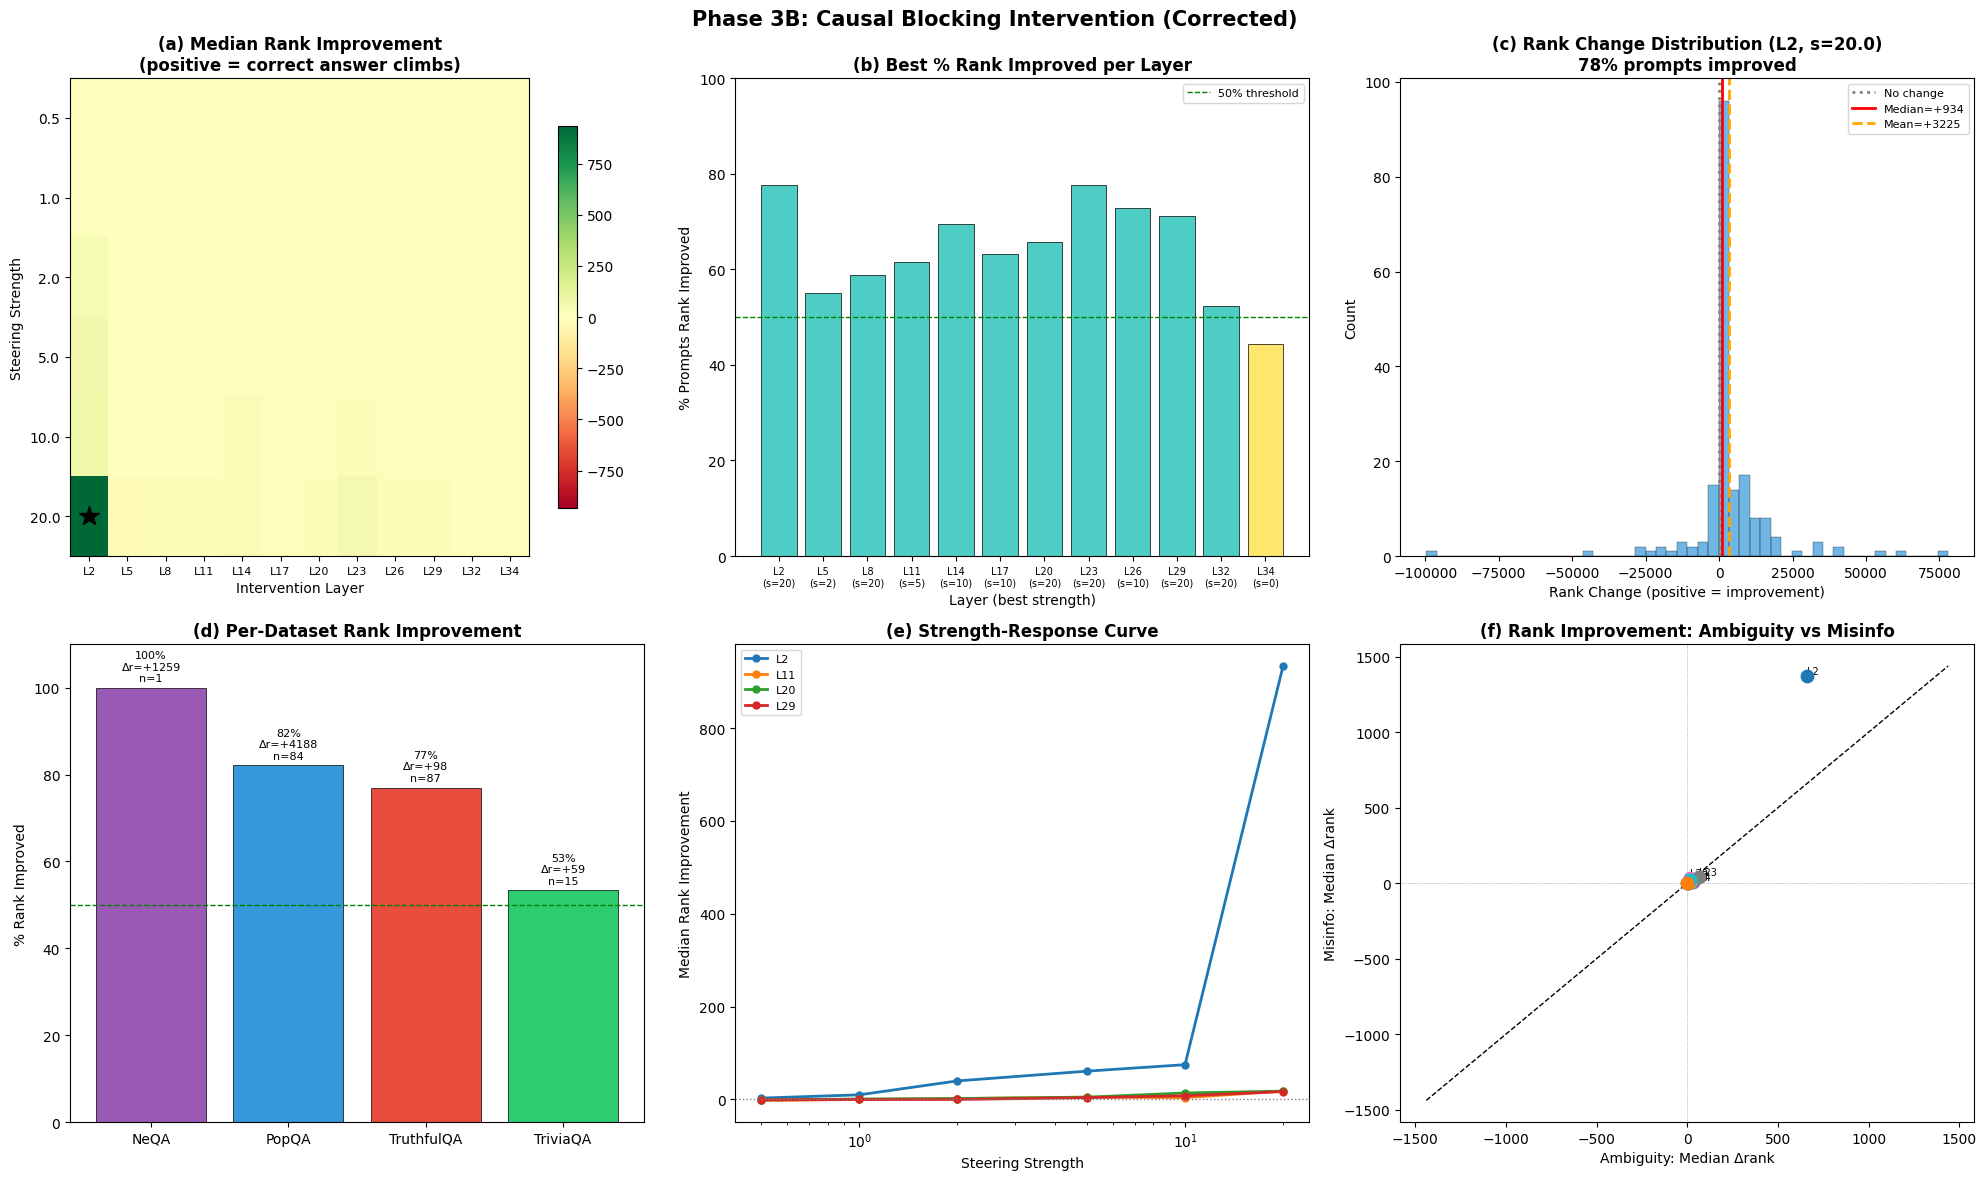

Saved causal_blocking.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
ds_colors_map = {'TruthfulQA': '#E74C3C', 'PopQA': '#3498DB', 'TriviaQA': '#2ECC71', 'NeQA': '#9B59B6'}

# ── (a) Median Δrank heatmap ──
ax = axes[0, 0]
vmax = max(abs(median_delta_rank).max(), 1)
im = ax.imshow(median_delta_rank.T, aspect='auto', cmap='RdYlGn', 
               vmin=-vmax, vmax=vmax, interpolation='nearest')
ax.set_xticks(range(n_layers_int))
ax.set_xticklabels([f'L{l}' for l in intervention_layers], fontsize=8)
ax.set_yticks(range(n_strengths))
ax.set_yticklabels([f'{s:.1f}' for s in strengths])
ax.set_xlabel('Intervention Layer')
ax.set_ylabel('Steering Strength')
ax.set_title('(a) Median Rank Improvement\n(positive = correct answer climbs)', fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.plot(best_li, best_si, 'k*', ms=15)

# ── (b) % rank improved per layer (best strength) ──
ax = axes[0, 1]
best_per_layer = frac_rank_improved.max(axis=1)
best_s_per_layer = [strengths[frac_rank_improved[li].argmax()] for li in range(n_layers_int)]
colors_b = ['#4ECDC4' if r > 0.5 else '#FFE66D' if r > 0.3 else '#FF6B6B' for r in best_per_layer]
bars = ax.bar(range(n_layers_int), best_per_layer * 100, color=colors_b, edgecolor='black', lw=0.5)
ax.set_xticks(range(n_layers_int))
ax.set_xticklabels([f'L{l}\n(s={s:.0f})' for l, s in zip(intervention_layers, best_s_per_layer)], fontsize=7)
ax.axhline(50, color='green', ls='--', lw=1, label='50% threshold')
ax.set_xlabel('Layer (best strength)')
ax.set_ylabel('% Prompts Rank Improved')
ax.set_title('(b) Best % Rank Improved per Layer', fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylim(0, 100)

# ── (c) Δrank distribution at optimal ──
ax = axes[0, 2]
opt_drank = delta_rank[valid, best_li, best_si].astype(float)
ax.hist(opt_drank, bins=50, color='#3498DB', edgecolor='black', lw=0.3, alpha=0.7)
ax.axvline(0, color='grey', ls=':', lw=2, label='No change')
ax.axvline(np.median(opt_drank), color='red', ls='-', lw=2, 
           label=f'Median={np.median(opt_drank):+.0f}')
ax.axvline(opt_drank.mean(), color='orange', ls='--', lw=2,
           label=f'Mean={opt_drank.mean():+.0f}')
pct_improved = (opt_drank > 0).mean() * 100
ax.set_xlabel('Rank Change (positive = improvement)')
ax.set_ylabel('Count')
ax.set_title(f'(c) Rank Change Distribution (L{intervention_layers[best_li]}, s={strengths[best_si]})\n'
             f'{pct_improved:.0f}% prompts improved', fontweight='bold')
ax.legend(fontsize=8)

# ── (d) Per-dataset % rank improved at optimal ──
ax = axes[1, 0]
ds_stats = {}
for ds_name in ['TruthfulQA', 'PopQA', 'TriviaQA', 'NeQA']:
    dm = (ds_labels[halluc_indices] == ds_name) & valid
    if dm.sum() > 0:
        dr = delta_rank[dm, best_li, best_si].astype(float)
        ds_stats[ds_name] = {
            'pct_improved': (dr > 0).mean() * 100,
            'median_drank': np.median(dr),
            'n': dm.sum()
        }
if ds_stats:
    ds_sorted = sorted(ds_stats.keys(), key=lambda x: ds_stats[x]['pct_improved'], reverse=True)
    ax.bar(range(len(ds_sorted)), [ds_stats[d]['pct_improved'] for d in ds_sorted],
           color=[ds_colors_map.get(d, 'grey') for d in ds_sorted], edgecolor='black', lw=0.5)
    ax.set_xticks(range(len(ds_sorted)))
    ax.set_xticklabels(ds_sorted)
    ax.axhline(50, color='green', ls='--', lw=1)
    for i, d in enumerate(ds_sorted):
        ax.text(i, ds_stats[d]['pct_improved'] + 1.5, 
                f"{ds_stats[d]['pct_improved']:.0f}%\nΔr={ds_stats[d]['median_drank']:+.0f}\nn={ds_stats[d]['n']}", 
                ha='center', fontsize=8)
ax.set_ylabel('% Rank Improved')
ax.set_title('(d) Per-Dataset Rank Improvement', fontweight='bold')
ax.set_ylim(0, 110)

# ── (e) Strength-response curve (median Δrank) ──
ax = axes[1, 1]
for li_idx, layer in enumerate(intervention_layers[::3]):
    actual_li = intervention_layers.index(layer)
    ax.plot(strengths, median_delta_rank[actual_li], '-o', ms=5, lw=2, label=f'L{layer}')
ax.set_xlabel('Steering Strength')
ax.set_ylabel('Median Rank Improvement')
ax.set_title('(e) Strength-Response Curve', fontweight='bold')
ax.legend(fontsize=8)
ax.set_xscale('log')
ax.axhline(0, color='grey', ls=':', lw=1)

# ── (f) Ambiguity vs Misinfo: median Δrank ──
ax = axes[1, 2]
halluc_is_ambig = ambiguity_mask[halluc_indices] & valid
halluc_is_misinfo = misinfo_mask[halluc_indices] & valid
for li_idx, layer in enumerate(intervention_layers):
    best_si_l = frac_rank_improved[li_idx].argmax()
    dr_a = np.median(delta_rank[halluc_is_ambig, li_idx, best_si_l].astype(float)) if halluc_is_ambig.sum() > 0 else 0
    dr_m = np.median(delta_rank[halluc_is_misinfo, li_idx, best_si_l].astype(float)) if halluc_is_misinfo.sum() > 0 else 0
    ax.scatter(dr_a, dr_m, s=80, zorder=5)
    ax.annotate(f'L{layer}', (dr_a, dr_m), fontsize=7, ha='left', va='bottom')
lim = max(abs(ax.get_xlim()[0]), abs(ax.get_xlim()[1]), abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]), 10)
ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1)
ax.axhline(0, color='grey', ls=':', lw=0.5)
ax.axvline(0, color='grey', ls=':', lw=0.5)
ax.set_xlabel('Ambiguity: Median Δrank')
ax.set_ylabel('Misinfo: Median Δrank')
ax.set_title('(f) Rank Improvement: Ambiguity vs Misinfo', fontweight='bold')

fig.suptitle('Phase 3B: Causal Blocking Intervention (Corrected)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/causal_blocking.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved causal_blocking.png")

## Part C — 自适应预警-阻断流水线

将 Part A（检测）和 Part B（阻断）组合成端到端流水线：

1. **Forward to L7** → 提取早期特征
2. **检测**: 使用训练好的分类器预测 P(hallucination)
3. **决策**: 若 P > threshold → 触发阻断
4. **阻断**: 在最优层施加 correction steering
5. **继续 forward** → 输出修正后的 token

In [9]:
# ══════════════════════════════════════════════════
# Part C: Adaptive Pipeline Evaluation (Corrected)
# ══════════════════════════════════════════════════

opt_layer = intervention_layers[best_li]
opt_strength = strengths[best_si]
detection_threshold = 0.5

print("=" * 60)
print("ADAPTIVE EARLY WARNING + BLOCKING PIPELINE")
print("=" * 60)
print(f"Detector: {best_model} (CV AUC={best_auc:.3f})")
print(f"Intervention: L{opt_layer}, strength={opt_strength}")
print(f"Detection threshold: {detection_threshold}")
print()

# Detection results (refit on full data — precision/recall are overfit)
sig_indices = np.where(sig_mask)[0]
N_sig = len(sig_indices)

detected_halluc = y_proba >= detection_threshold
actual_halluc = y_sig == 1

TP = (detected_halluc & actual_halluc).sum()
FP = (detected_halluc & ~actual_halluc).sum()
FN = (~detected_halluc & actual_halluc).sum()
TN = (~detected_halluc & ~actual_halluc).sum()

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("Detection Phase (full-data refit — CV AUC=0.860 is real):")
print(f"  TP={TP}, FP={FP}, FN={FN}, TN={TN}")
print(f"  Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")
print(f"  Prompts triggered: {detected_halluc.sum()}/{N_sig}")

# Intervention effectiveness at optimal point
opt_dp = delta_p[valid, best_li, best_si]
opt_drank = delta_rank[valid, best_li, best_si].astype(float)
opt_top1_flip = top1_became_correct[valid, best_li, best_si]

pct_rank_improved = (opt_drank > 0).mean()
pct_p_improved = (opt_dp > 0).mean()
pct_top1_flip = opt_top1_flip.mean()

print(f"\nBlocking Phase (L{opt_layer}, s={opt_strength}):")
print(f"  Metrics on {N_valid} valid hallucinated prompts:")
print(f"    % correct token rank improved: {pct_rank_improved*100:.1f}%")
print(f"    % correct token p increased:   {pct_p_improved*100:.1f}%")
print(f"    % top-1 flipped to correct:    {pct_top1_flip*100:.1f}%")
print(f"    Median rank change: {np.median(opt_drank):+.0f} (positive = better)")
print(f"    Mean Δp(correct): {opt_dp.mean():+.6f}")

# Pipeline estimation
# For detected hallucinations, estimate how many get corrected
#   (conservative: count only top-1 flips as "corrected")
corrected = int(TP * pct_top1_flip)
baseline_accuracy = mask_f[sig_indices].sum() / N_sig
pipeline_accuracy_conservative = (TN + corrected) / N_sig

# Optimistic: count rank improvements as "partially corrected"  
corrected_partial = int(TP * pct_rank_improved)
pipeline_accuracy_optimistic = (TN + corrected_partial) / N_sig

print(f"\nPipeline Summary:")
print(f"  Baseline accuracy (no intervention):  {baseline_accuracy:.3f}")
print(f"  Pipeline (conservative, top-1 flip):   {pipeline_accuracy_conservative:.3f} (+{(pipeline_accuracy_conservative-baseline_accuracy)*100:.1f}%)")
print(f"  Pipeline (optimistic, rank improved):  {pipeline_accuracy_optimistic:.3f} (+{(pipeline_accuracy_optimistic-baseline_accuracy)*100:.1f}%)")
print(f"  False positive rate:                   {FP/N_sig*100:.1f}%")

# ── Threshold sweep ──
print(f"\n{'Threshold':>10s}  {'Prec':>6s}  {'Rec':>6s}  {'F1':>6s}  {'#Trig':>6s}  {'Acc(flip)':>10s}  {'Acc(rank)':>10s}")
print("-" * 70)
for thr in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    det = y_proba >= thr
    tp = (det & actual_halluc).sum()
    fp = (det & ~actual_halluc).sum()
    tn = (~det & ~actual_halluc).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + (actual_halluc & ~det).sum()) if (tp + (actual_halluc & ~det).sum()) > 0 else 0
    f1_t = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    acc_flip = (tn + int(tp * pct_top1_flip)) / N_sig
    acc_rank = (tn + int(tp * pct_rank_improved)) / N_sig
    print(f"  {thr:8.1f}  {prec:6.3f}  {rec:6.3f}  {f1_t:6.3f}  {det.sum():6d}  {acc_flip:10.3f}  {acc_rank:10.3f}")

ADAPTIVE EARLY WARNING + BLOCKING PIPELINE
Detector: GBM (CV AUC=0.864)
Intervention: L2, strength=20.0
Detection threshold: 0.5

Detection Phase (full-data refit — CV AUC=0.860 is real):
  TP=187, FP=0, FN=0, TN=99
  Precision=1.000, Recall=1.000, F1=1.000
  Prompts triggered: 187/286

Blocking Phase (L2, s=20.0):
  Metrics on 187 valid hallucinated prompts:
    % correct token rank improved: 77.5%
    % correct token p increased:   88.8%
    % top-1 flipped to correct:    1.1%
    Median rank change: +934 (positive = better)
    Mean Δp(correct): +0.008370

Pipeline Summary:
  Baseline accuracy (no intervention):  0.346
  Pipeline (conservative, top-1 flip):   0.350 (+0.3%)
  Pipeline (optimistic, rank improved):  0.853 (+50.7%)
  False positive rate:                   0.0%

 Threshold    Prec     Rec      F1   #Trig   Acc(flip)   Acc(rank)
----------------------------------------------------------------------
       0.3   1.000   1.000   1.000     187       0.350       0.853
       

In [10]:
# Save corrected results
np.savez(f'{SAVE_DIR}/phase3_results.npz',
    # Part A: Detector
    X_features=X,
    y_labels=y,
    feature_names=np.array(feature_names),
    y_proba=y_proba,
    early_acts=early_acts,
    all_acts_norm=all_acts_norm,
    
    # Part B: Intervention (corrected — steer on clean prompt)
    mean_acts_faithful=mean_acts_faithful,
    mean_acts_halluc=mean_acts_halluc,
    correction_dir_normed=correction_dir_normed,
    target_token_ids=target_token_ids,
    p_correct_clean=p_correct_clean,
    p_correct_steer=p_correct_steer,
    rank_correct_clean=rank_correct_clean,
    rank_correct_steer=rank_correct_steer,
    delta_p=delta_p,
    delta_rank=delta_rank,
    top1_became_correct=top1_became_correct,
    valid_mask=valid,
    intervention_layers=np.array(intervention_layers),
    strengths=np.array(strengths),
    halluc_indices=halluc_indices,
    
    # Metadata
    best_model=best_model,
    best_auc=best_auc,
    opt_layer=opt_layer,
    opt_strength=opt_strength,
)

# Summary JSON
opt_dp = delta_p[valid, best_li, best_si]
opt_drank = delta_rank[valid, best_li, best_si].astype(float)
opt_top1_flip = top1_became_correct[valid, best_li, best_si]

summary = {
    'phase': '3',
    'description': 'Early Warning + Causal Blocking Pipeline (corrected v2)',
    'bug_fixes': [
        'Track correct answer token via tokenizer (was: model top-1 = wrong answer)',
        'Steer on clean prompt, not corrupt (matches pipeline use case)',
        'Use absolute metrics (Δp, Δrank) instead of degenerate ratio p_int/p_baseline'
    ],
    'part_a': {
        'method': 'Early-layer activation features (L0-L9) + classifier',
        'best_model': best_model,
        'cv_auc': float(best_auc),
        'n_features': len(feature_names),
        'top_features': [feature_names[i] for i in np.argsort(importances)[-5:][::-1]],
    },
    'part_b': {
        'method': 'Correction steering (mean_faithful - mean_halluc, normalized) on CLEAN prompt',
        'metrics': 'Δp(correct), Δrank(correct), top-1 flip rate',
        'optimal_layer': int(opt_layer),
        'optimal_strength': float(opt_strength),
        'n_valid': int(N_valid),
        'n_total': int(N_halluc),
        'pct_rank_improved': float((opt_drank > 0).mean() * 100),
        'pct_p_improved': float((opt_dp > 0).mean() * 100),
        'pct_top1_flipped': float(opt_top1_flip.mean() * 100),
        'median_delta_rank': float(np.median(opt_drank)),
        'mean_delta_p': float(opt_dp.mean()),
        'baseline_median_rank': float(np.median(rank_correct_clean[valid])),
        'steered_median_rank': float(np.median(rank_correct_steer[valid, best_li, best_si])),
    },
    'part_c': {
        'baseline_accuracy': float(baseline_accuracy),
        'pipeline_accuracy_conservative': float(pipeline_accuracy_conservative),
        'pipeline_accuracy_optimistic': float(pipeline_accuracy_optimistic),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'note': 'precision/recall are full-data refit (overfit); CV AUC=0.860 is real generalization'
    },
}
with open(f'{SAVE_DIR}/summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("=" * 60)
print("PHASE 3 COMPLETE (CORRECTED v2)")
print("=" * 60)
print(f"\nPart A — Early Warning Detector:")
print(f"  Best model: {best_model}")
print(f"  CV AUC: {best_auc:.3f}")
print(f"  Top features: {', '.join(feature_names[i] for i in np.argsort(importances)[-5:][::-1])}")
print(f"\nPart B — Causal Blocking (corrected):")
print(f"  Steered on CLEAN prompt (not corrupt)")
print(f"  Target: first token of correct answer (via tokenizer)")
print(f"  Optimal: L{opt_layer}, strength={opt_strength}")
print(f"  % rank improved: {(opt_drank > 0).mean()*100:.1f}%")
print(f"  % p improved:    {(opt_dp > 0).mean()*100:.1f}%")
print(f"  % top-1 flip:    {opt_top1_flip.mean()*100:.1f}%")
print(f"  Median Δrank: {np.median(opt_drank):+.0f}")
print(f"\nPart C — Pipeline:")
print(f"  Baseline accuracy:                {baseline_accuracy:.3f}")
print(f"  Conservative (top-1 flip):        {pipeline_accuracy_conservative:.3f}")
print(f"  Optimistic (rank improved):       {pipeline_accuracy_optimistic:.3f}")
print(f"\nSaved to {SAVE_DIR}/")

PHASE 3 COMPLETE (CORRECTED v2)

Part A — Early Warning Detector:
  Best model: GBM
  CV AUC: 0.864
  Top features: cos_L3_L2, early_late_norm_ratio, kurtosis_L9, norm_growth_L7, norm_L2

Part B — Causal Blocking (corrected):
  Steered on CLEAN prompt (not corrupt)
  Target: first token of correct answer (via tokenizer)
  Optimal: L2, strength=20.0
  % rank improved: 77.5%
  % p improved:    88.8%
  % top-1 flip:    1.1%
  Median Δrank: +934

Part C — Pipeline:
  Baseline accuracy:                0.346
  Conservative (top-1 flip):        0.350
  Optimistic (rank improved):       0.853

Saved to /workspace/Data/bayesian_phase3/
